### import necessary libraries

In [49]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage,dendrogram
from sklearn.cluster import DBSCAN 

### data collection

In [1]:
from sklearn.datasets import make_moons

In [11]:
x,y = make_moons(100)

In [12]:
y

array([1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1])

In [13]:
import pandas as pd
data = pd.DataFrame(x)
data

,0,1
0,2.000000,0.500000
1,0.281651,-0.195683
2,0.967295,0.253655
3,-0.981559,0.191159
4,-0.997945,0.064070
...,...,...
95,0.032052,0.999486
96,0.327699,-0.240278
97,0.376510,-0.281831
98,0.871319,0.490718


In [14]:
data.columns = ["f1","f2"]
data

,f1,f2
0,2.000000,0.500000
1,0.281651,-0.195683
2,0.967295,0.253655
3,-0.981559,0.191159
4,-0.997945,0.064070
...,...,...
95,0.032052,0.999486
96,0.327699,-0.240278
97,0.376510,-0.281831
98,0.871319,0.490718


In [16]:
data["class"] = y
data.head()

,f1,f2,class
0,2.000000,0.500000,1
1,0.281651,-0.195683,1
2,0.967295,0.253655,0
3,-0.981559,0.191159,0
4,-0.997945,0.064070,0


C:\Users\Warrior\AppData\Local\Temp\ipykernel_484\163426448.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data["f1"],data["f2"],cmap=plt.cm.Accent)


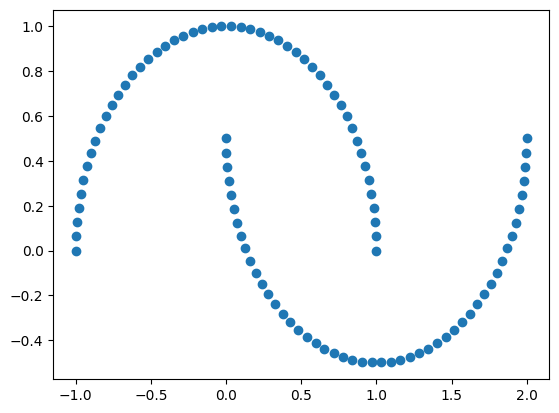

In [19]:
from matplotlib import pyplot as plt
plt.scatter(data["f1"],data["f2"],cmap=plt.cm.Accent)

### Using K means for moon data

In [28]:
kmodel = KMeans(n_clusters = 2, max_iter = 600)

In [29]:
kmodel.fit(data.iloc[:,:2])

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,600
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [31]:
claas_pr=kmodel.predict(data.iloc[:,:2])

In [32]:
data["class_pr"]=claas_pr

In [33]:
data.head()

,f1,f2,class,class_pr
0,2.000000,0.500000,1,0
1,0.281651,-0.195683,1,0
2,0.967295,0.253655,0,0
3,-0.981559,0.191159,0,1
4,-0.997945,0.064070,0,1


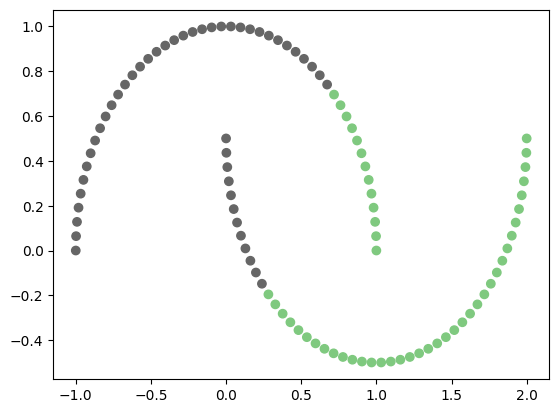

In [34]:
plt.scatter(data["f1"],data["f2"],c=data["class_pr"],cmap=plt.cm.Accent)

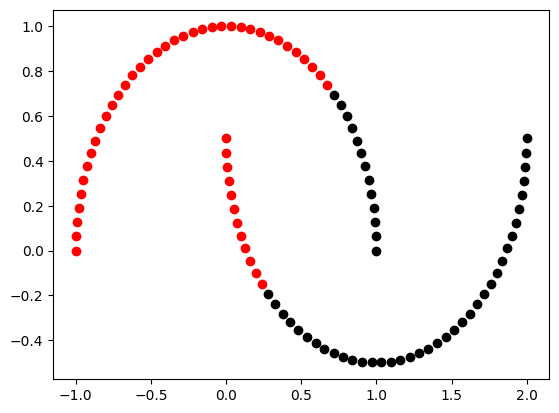

In [35]:
plt.scatter(data[data["class_pr"]==1].iloc[:,0],data[data["class_pr"]==1].iloc[:,1],color="red")
plt.scatter(data[data["class_pr"]==0].iloc[:,0],data[data["class_pr"]==0].iloc[:,1],color="black")

### Result : Not accurate

### Using Hierarchical Clustering

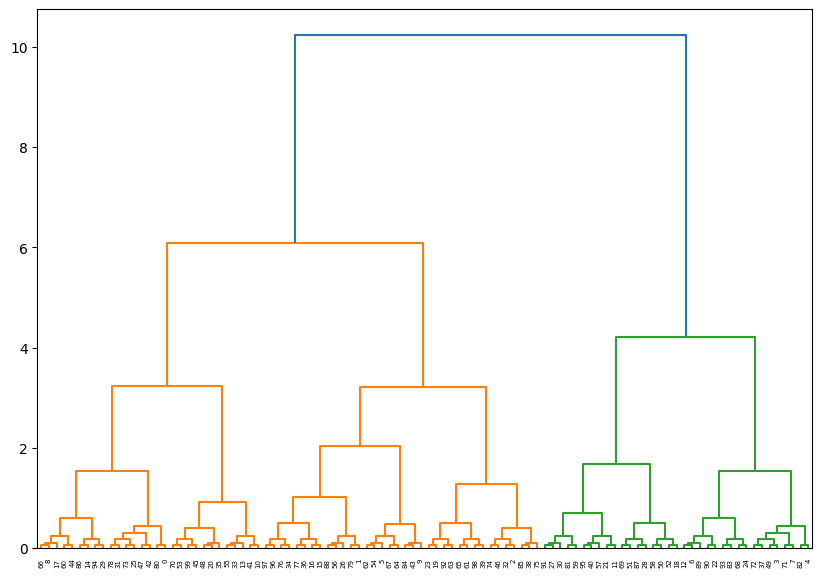

In [42]:
linked = linkage(data.iloc[:,:2], 'ward')

plt.figure(figsize=(10, 7))
dendrogram(linked,
            orientation='top',
            distance_sort='descending',
            show_leaf_counts=True)
plt.show()

In [44]:
cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage="single")
claas_pr= cluster.fit_predict(data.iloc[:,:2])

In [45]:
data["class_pr"]=claas_pr

In [46]:
data.head(20)

,f1,f2,class,class_pr
0,2.000000,0.500000,1,0
1,0.281651,-0.195683,1,0
2,0.967295,0.253655,0,1
3,-0.981559,0.191159,0,1
4,-0.997945,0.064070,0,1
5,0.032705,0.246345,1,0
6,-0.838088,0.545535,0,1
7,-0.900969,0.433884,0,1
8,1.801414,-0.098111,1,0
9,0.099031,0.066116,1,0


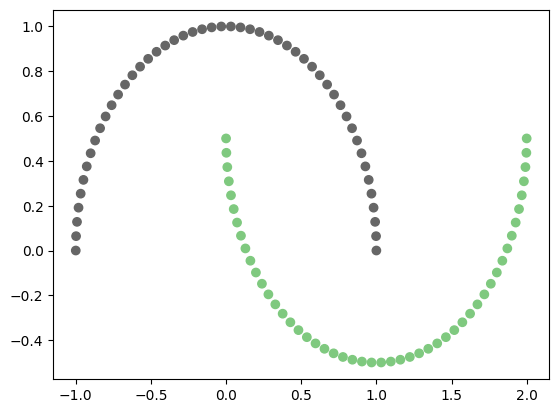

In [47]:
plt.scatter(data["f1"],data["f2"],c=data["class_pr"],cmap=plt.cm.Accent)

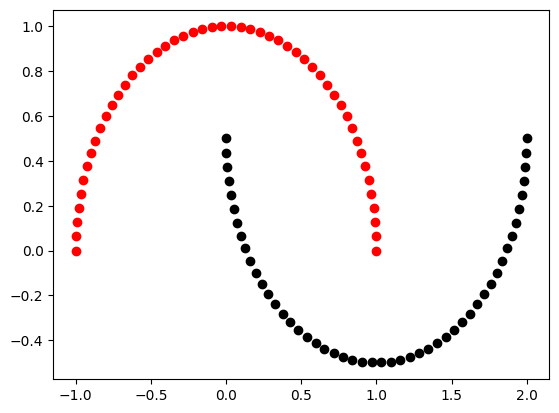

In [48]:
plt.scatter(data[data["class_pr"]==1].iloc[:,0],data[data["class_pr"]==1].iloc[:,1],color="red")
plt.scatter(data[data["class_pr"]==0].iloc[:,0],data[data["class_pr"]==0].iloc[:,1],color="black")

### Result : Correct clustering well done

### Apply DBSCAN

In [50]:
min_samples=2 #n

In [51]:
dbs=DBSCAN(min_samples=2,eps=0.2)
claas_pr=dbs.fit_predict(data.iloc[:,:2])

In [52]:
claas_pr

array([0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0])

In [53]:
data["class_pr"]=claas_pr
data

,f1,f2,class,class_pr
0,2.000000,0.500000,1,0
1,0.281651,-0.195683,1,0
2,0.967295,0.253655,0,1
3,-0.981559,0.191159,0,1
4,-0.997945,0.064070,0,1
...,...,...,...,...
95,0.032052,0.999486,0,1
96,0.327699,-0.240278,1,0
97,0.376510,-0.281831,1,0
98,0.871319,0.490718,0,1


Text(0, 0.5, 'f2')

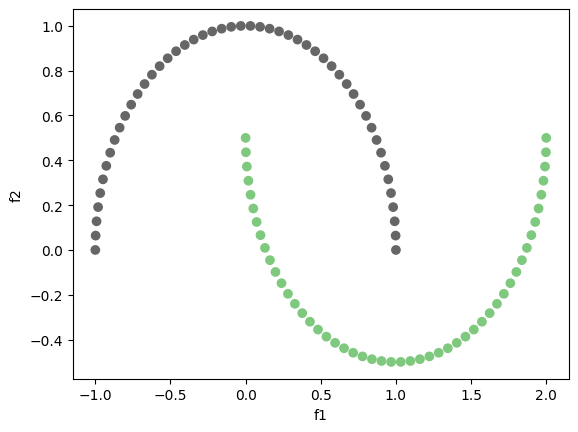

In [54]:
import matplotlib.pyplot as plt
plt.scatter(data["f1"],data["f2"],c=data["class_pr"],cmap=plt.cm.Accent)
plt.xlabel("f1")
plt.ylabel("f2")

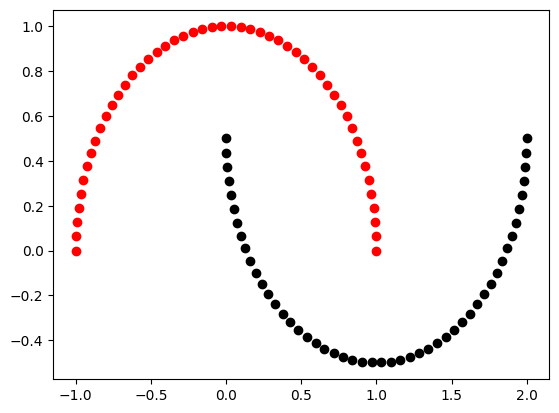

In [55]:
plt.scatter(data[data["class_pr"]==1].iloc[:,0],data[data["class_pr"]==1].iloc[:,1],color="red")
plt.scatter(data[data["class_pr"]==0].iloc[:,0],data[data["class_pr"]==0].iloc[:,1],color="black")

### Result : Correct Clustering. Well Done